In [1]:
import os
from roboflow import Roboflow
rf = Roboflow(api_key=os.environ.get("ROBOFLOW_API_KEY"))
project = rf.workspace("fyp-vfrgn").project("7-classes-vehicle")
version = project.version(1)
dataset = version.download("coco")
import json
with open("7-classes-vehicle-1/test/_annotations.coco.json") as f:
    data = json.load(f)
for cat in data["categories"]:
    print(cat)

loading Roboflow workspace...
loading Roboflow project...
{'id': 0, 'name': 'cars-counter', 'supercategory': 'none'}
{'id': 1, 'name': 'Bus', 'supercategory': 'cars-counter'}
{'id': 2, 'name': 'Motorcycle', 'supercategory': 'cars-counter'}
{'id': 3, 'name': 'Pickup', 'supercategory': 'cars-counter'}
{'id': 4, 'name': 'Sedan', 'supercategory': 'cars-counter'}
{'id': 5, 'name': 'Suv', 'supercategory': 'cars-counter'}
{'id': 6, 'name': 'Truck', 'supercategory': 'cars-counter'}
{'id': 7, 'name': 'Van', 'supercategory': 'cars-counter'}


# 🚗 Vehicle Detection Model Benchmark
Benchmarks **YOLOv26s**, **YOLOv26m** (PyTorch & TensorRT) and **RF-DETR Small/Medium** on the COCO test set.

**Metrics:** Precision · Recall · F1 · mAP@50 · mAP@50:95 · mAP@75 · Per-Class AP · Latency · FPS

## 📦 Cell 1 — Install / Import

In [2]:
# Uncomment if needed
# !pip install ultralytics supervision rfdetr pycocotools pandas matplotlib seaborn

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from copy import deepcopy
from tqdm.notebook import tqdm

import torch
import cv2
from PIL import Image

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

import supervision as sv
from ultralytics import YOLO

warnings.filterwarnings('ignore')
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Supervision: {sv.__version__}")

PyTorch  : 2.11.0+cu126
CUDA     : True — NVIDIA GeForce RTX 4060
Supervision: 0.27.0.post2


## ⚙️ Cell 2 — Paths & Config

In [3]:
# ── COCO annotation file (from version 1 / 'coco' download) ──────────────────
COCO_ANNOT_JSON   = "7-classes-vehicle-1/test/_annotations.coco.json"   # adjust if needed
COCO_IMAGES_DIR   = "7-classes-vehicle-1/test"                           # adjust if needed

# ── Model weights ─────────────────────────────────────────────────────────────
YOLO_S_PT  = r"runs/detect/vehicle_detection/yolo26s/weights/best.pt"
YOLO_S_TRT = r"runs/detect/vehicle_detection/yolo26s/weights/best.engine"
YOLO_M_PT  = r"runs/detect/vehicle_detection/yolo26m/weights/best.pt"
YOLO_M_TRT = r"runs/detect/vehicle_detection/yolo26m/weights/best.engine"
RFDETR_S   = r"output_small/checkpoint_best_total.pth"
RFDETR_M   = r"output_medium/checkpoint_best_total.pth"

# ── Inference settings ────────────────────────────────────────────────────────
CONF_THRESHOLD   = 0.25
IOU_THRESHOLD    = 0.5
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
WARMUP_RUNS      = 10     # ignored from latency measurement
LATENCY_RUNS     = 100    # number of images used for stable latency estimate
IMG_SIZE_YOLO    = 640
IMG_SIZE_RFDETR_S = 512   # must match training resolution
IMG_SIZE_RFDETR_M = 576   # must match training resolution

# ── Sanity check paths ────────────────────────────────────────────────────────
for label, p in [
    ("COCO annotations", COCO_ANNOT_JSON),
    ("COCO images dir",  COCO_IMAGES_DIR),
    ("YOLO-S .pt",       YOLO_S_PT),
    ("YOLO-S .engine",   YOLO_S_TRT),
    ("YOLO-M .pt",       YOLO_M_PT),
    ("YOLO-M .engine",   YOLO_M_TRT),
    ("RFDETR-S .pth",    RFDETR_S),
    ("RFDETR-M .pth",    RFDETR_M),
]:
    status = "✅" if os.path.exists(p) else "❌  MISSING"
    print(f"{status}  {label:25s}  {p}")

✅  COCO annotations           7-classes-vehicle-1/test/_annotations.coco.json
✅  COCO images dir            7-classes-vehicle-1/test
✅  YOLO-S .pt                 runs/detect/vehicle_detection/yolo26s/weights/best.pt
✅  YOLO-S .engine             runs/detect/vehicle_detection/yolo26s/weights/best.engine
✅  YOLO-M .pt                 runs/detect/vehicle_detection/yolo26m/weights/best.pt
✅  YOLO-M .engine             runs/detect/vehicle_detection/yolo26m/weights/best.engine
✅  RFDETR-S .pth              output_small/checkpoint_best_total.pth
✅  RFDETR-M .pth              output_medium/checkpoint_best_total.pth


## 📂 Cell 3 — Load COCO Ground Truth & Build Image List

In [4]:
coco_gt = COCO(COCO_ANNOT_JSON)

# Map image_id → file path
img_id_to_path = {
    img_info["id"]: os.path.join(COCO_IMAGES_DIR, img_info["file_name"])
    for img_info in coco_gt.dataset["images"]
}
image_ids   = sorted(img_id_to_path.keys())

# ── Build class mappings (handle extra 'cars-counter' category) ───────────
all_categories = {cat["id"]: cat["name"] for cat in coco_gt.dataset["categories"]}
EXCLUDED_CATS  = {"cars-counter"}

class_names = {cid: name for cid, name in all_categories.items() if name not in EXCLUDED_CATS}
cat_ids     = sorted(class_names.keys())

# YOLO class names in data.yaml order
YOLO_CLASS_NAMES = ["Bus", "Motorcycle", "Pickup", "Sedan", "Suv", "Truck", "Van"]
coco_name_to_id  = {name: cid for cid, name in all_categories.items()}

yolo_cls_to_coco_id = {i: coco_name_to_id[name] for i, name in enumerate(YOLO_CLASS_NAMES)}

# RF-DETR was trained on the COCO format directly (8 classes including cars-counter),
# so its predicted class_id already equals the COCO category_id.
rfdetr_cls_to_coco_id = {i: i for i in range(len(all_categories))}

# Set of valid COCO category IDs for filtering predictions before evaluation
EVAL_CAT_IDS = set(cat_ids)

print(f"Test images : {len(image_ids)}")
print(f"All COCO categories : {all_categories}")
print(f"Excluded            : {EXCLUDED_CATS}")
print(f"Eval categories     : {class_names}")
print(f"YOLO→COCO mapping   : {yolo_cls_to_coco_id}")
print(f"RFDETR→COCO mapping : {rfdetr_cls_to_coco_id}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Test images : 728
All COCO categories : {0: 'cars-counter', 1: 'Bus', 2: 'Motorcycle', 3: 'Pickup', 4: 'Sedan', 5: 'Suv', 6: 'Truck', 7: 'Van'}
Excluded            : {'cars-counter'}
Eval categories     : {1: 'Bus', 2: 'Motorcycle', 3: 'Pickup', 4: 'Sedan', 5: 'Suv', 6: 'Truck', 7: 'Van'}
YOLO→COCO mapping   : {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7}
RFDETR→COCO mapping : {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}


## 🔧 Cell 4 — Shared Evaluation Helpers

In [5]:
def run_coco_eval(coco_gt: COCO, predictions: list, eval_cat_ids: list,
                  iou_type: str = "bbox") -> COCOeval:
    """Run COCO evaluation on the specified category IDs only."""
    if not predictions:
        raise ValueError("No predictions were produced.")
    coco_dt = coco_gt.loadRes(predictions)
    ev = COCOeval(coco_gt, coco_dt, iou_type)
    ev.params.catIds = eval_cat_ids
    ev.params.maxDets = [1, 100, 300]
    ev.evaluate()
    ev.accumulate()
    ev.summarize()
    return ev


def extract_metrics(ev: COCOeval, coco_gt: COCO, cat_ids: list, class_names: dict) -> dict:
    """Pull mAP@50, mAP@75, mAP@50:95 and per-class AP from a COCOeval object.

    All metrics are computed at maxDets=300 (index 2 in the M dimension)
    to match YOLO's default max_det=300.
    """
    prec = ev.eval["precision"]          # (T, R, K, A, M)
    M_IDX = 2                            # maxDets=300

    # mAP@50:95 — mean over all 10 IoU thresholds (0.50:0.05:0.95)
    all_ap = prec[:, :, :, 0, M_IDX]    # (T, R, K) at area=all
    all_ap = all_ap[all_ap > -1]
    map_50_95 = float(all_ap.mean()) if len(all_ap) else 0.0

    # mAP@50 — IoU threshold index 0 = 0.50
    ap50 = prec[0, :, :, 0, M_IDX]
    ap50 = ap50[ap50 > -1]
    map_50 = float(ap50.mean()) if len(ap50) else 0.0

    # mAP@75 — IoU threshold index 5 = 0.75
    ap75 = prec[5, :, :, 0, M_IDX]
    ap75 = ap75[ap75 > -1]
    map_75 = float(ap75.mean()) if len(ap75) else 0.0

    # Per-class AP@50:95
    per_class_ap = {}
    for k, cat_id in enumerate(sorted(ev.params.catIds)):
        ap_vals = prec[:, :, k, 0, M_IDX]
        ap_vals = ap_vals[ap_vals > -1]
        per_class_ap[class_names.get(cat_id, str(cat_id))] = (
            float(ap_vals.mean()) if len(ap_vals) else 0.0
        )

    return {
        "mAP@50:95" : round(map_50_95, 4),
        "mAP@50"    : round(map_50, 4),
        "mAP@75"    : round(map_75, 4),
        "per_class_ap": {k: round(v, 4) for k, v in per_class_ap.items()},
    }


def _compute_iou(box_a, box_b):
    """IoU between two [x, y, w, h] COCO-format boxes."""
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    ix1 = max(ax, bx)
    iy1 = max(ay, by)
    ix2 = min(ax + aw, bx + bw)
    iy2 = min(ay + ah, by + bh)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0


def f1_sweep(coco_gt: COCO, predictions: list, iou_threshold: float = 0.5,
             n_thresholds: int = 101) -> dict:
    """
    Sweep confidence thresholds to find the one maximising F1 (IoU=0.50),
    matching the methodology used by both YOLO val() and RF-DETR training logs.

    Returns dict with best F1, Precision, Recall and the optimal threshold.
    """
    if not predictions:
        return {"F1": 0.0, "Precision": 0.0, "Recall": 0.0, "Best Conf": 0.0}

    gt_by_image = {}
    for ann in coco_gt.dataset["annotations"]:
        gt_by_image.setdefault(ann["image_id"], []).append(ann)
    total_gt = sum(len(v) for v in gt_by_image.values())

    preds_sorted = sorted(predictions, key=lambda p: p["score"], reverse=True)
    scores = np.array([p["score"] for p in preds_sorted])
    thresholds = np.linspace(0.0, 1.0, n_thresholds)

    best_f1, best_p, best_r, best_thr = 0.0, 0.0, 0.0, 0.0

    for thr in thresholds:
        mask = scores >= thr
        preds_at_thr = [p for p, m in zip(preds_sorted, mask) if m]

        matched_gt = set()
        tp = 0
        fp = 0

        for pred in preds_at_thr:
            img_id = pred["image_id"]
            cat_id = pred["category_id"]
            pred_box = pred["bbox"]

            gt_anns = gt_by_image.get(img_id, [])
            best_iou = 0.0
            best_gt_id = None

            for gt in gt_anns:
                if gt["category_id"] != cat_id:
                    continue
                gt_key = gt["id"]
                if gt_key in matched_gt:
                    continue
                iou = _compute_iou(pred_box, gt["bbox"])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_id = gt_key

            if best_iou >= iou_threshold and best_gt_id is not None:
                tp += 1
                matched_gt.add(best_gt_id)
            else:
                fp += 1

        fn = total_gt - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_val    = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        if f1_val > best_f1:
            best_f1, best_p, best_r, best_thr = f1_val, precision, recall, float(thr)

    return {
        "F1"        : round(best_f1,  4),
        "Precision" : round(best_p,   4),
        "Recall"    : round(best_r,   4),
        "Best Conf" : round(best_thr, 3),
    }


def measure_latency(infer_fn, image_paths: list,
                    warmup: int = WARMUP_RUNS,
                    runs: int   = LATENCY_RUNS) -> dict:
    """
    Warm up then time `infer_fn` on the first `runs` images.
    Returns mean latency (ms) and FPS.
    """
    paths = image_paths[:max(warmup, runs)]

    # warm-up
    for p in paths[:warmup]:
        infer_fn(p)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for p in tqdm(paths[:runs], desc="Latency", leave=False):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        infer_fn(p)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

    mean_ms = float(np.mean(times)) * 1000
    fps     = 1000 / mean_ms
    return {"Latency (ms)": round(mean_ms, 2), "FPS": round(fps, 1)}


print("Helpers loaded ✅")

Helpers loaded ✅


## 🟦 Cell 5 — YOLO Benchmark (PT & TRT)

In [6]:
def yolo_predictions_coco(model, image_ids, img_id_to_path,
                           cls_to_coco_id, conf=CONF_THRESHOLD, imgsz=IMG_SIZE_YOLO,
                           device=None):
    """Run YOLO inference on all test images; return COCO-format prediction list."""
    preds = []
    for img_id in tqdm(image_ids, desc="YOLO inference"):
        img_path = img_id_to_path[img_id]
        results   = model(img_path, conf=conf, imgsz=imgsz, device=device, verbose=False)[0]
        boxes = results.boxes
        if boxes is None or len(boxes) == 0:
            continue
        # xyxy → xywh for COCO
        xyxy   = boxes.xyxy.cpu().numpy()
        scores = boxes.conf.cpu().numpy()
        clss   = boxes.cls.cpu().numpy().astype(int)
        for (x1, y1, x2, y2), sc, cl in zip(xyxy, scores, clss):
            preds.append({
                "image_id"   : img_id,
                "category_id": cls_to_coco_id.get(cl, cl + 1),
                "bbox"       : [float(x1), float(y1),
                                float(x2 - x1), float(y2 - y1)],
                "score"      : float(sc),
            })
    return preds


def benchmark_yolo(name, weight_path, image_ids, img_id_to_path,
                   cls_to_coco_id, coco_gt):
    print(f"\n{'='*60}")
    print(f"  Benchmarking: {name}")
    print(f"{'='*60}")

    model = YOLO(weight_path)
    is_pytorch = weight_path.endswith(".pt")
    if is_pytorch:
        model.to(DEVICE)

    # --- Predictions (use very low conf to capture full score range for F1 sweep) ---
    preds = yolo_predictions_coco(model, image_ids, img_id_to_path,
                                  cls_to_coco_id, conf=0.001,
                                  device=DEVICE)
    preds = [p for p in preds if p["category_id"] in EVAL_CAT_IDS]

    # --- COCO Eval (only on the 7 vehicle classes) --------------------------
    ev      = run_coco_eval(coco_gt, preds, cat_ids)
    metrics = extract_metrics(ev, coco_gt, cat_ids, class_names)

    # --- F1 sweep (find optimal confidence threshold) -----------------------
    f1_metrics = f1_sweep(coco_gt, preds)
    metrics.update(f1_metrics)

    # --- Latency ------------------------------------------------------------
    all_paths = list(img_id_to_path.values())

    def infer_single(p):
        return model(p, conf=CONF_THRESHOLD, imgsz=IMG_SIZE_YOLO, device=DEVICE, verbose=False)

    lat = measure_latency(infer_single, all_paths)
    metrics.update(lat)

    print(f"  mAP@50      : {metrics['mAP@50']}")
    print(f"  mAP@50:95   : {metrics['mAP@50:95']}")
    print(f"  mAP@75      : {metrics['mAP@75']}")
    print(f"  F1          : {metrics['F1']}  (at conf={metrics['Best Conf']})")
    print(f"  Precision   : {metrics['Precision']}")
    print(f"  Recall      : {metrics['Recall']}")
    print(f"  Latency(ms) : {metrics['Latency (ms)']}")
    print(f"  FPS         : {metrics['FPS']}")

    del model
    torch.cuda.empty_cache()
    return metrics


yolo_models = [
    ("YOLOv26s (PyTorch)",  YOLO_S_PT),
    ("YOLOv26s (TensorRT)", YOLO_S_TRT),
    ("YOLOv26m (PyTorch)",  YOLO_M_PT),
    ("YOLOv26m (TensorRT)", YOLO_M_TRT),
]

all_results = {}
for name, path in yolo_models:
    all_results[name] = benchmark_yolo(
        name, path, image_ids, img_id_to_path,
        yolo_cls_to_coco_id, coco_gt
    )


  Benchmarking: YOLOv26s (PyTorch)


YOLO inference:   0%|          | 0/728 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.99s).
Accumulating evaluation results...
DONE (t=0.20s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.557
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=300 ] = 0.841
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=300 ] = 0.668
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=300 ] = 0.282
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=300 ] = 0.558
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=300 ] = 0.680
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.433
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.686
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 ] = 0.686
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=30

Latency:   0%|          | 0/100 [00:00<?, ?it/s]

  mAP@50      : 0.8405
  mAP@50:95   : 0.5564
  mAP@75      : 0.6685
  F1          : 0.8209  (at conf=0.51)
  Precision   : 0.8131
  Recall      : 0.8289
  Latency(ms) : 12.73
  FPS         : 78.6

  Benchmarking: YOLOv26s (TensorRT)


...

  mAP@50      : 0.8348
  mAP@50:95   : 0.5538
  mAP@75      : 0.6742
  F1          : 0.83  (at conf=0.52)
  Precision   : 0.8238
  Recall      : 0.8363
  Latency(ms) : 14.19
  FPS         : 70.5

  Benchmarking: YOLOv26m (TensorRT)


YOLO inference:   0%|          | 0/728 [00:00<?, ?it/s]

Loading runs/detect/vehicle_detection/yolo26m/weights/best.engine for TensorRT inference...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.86s).
Accumulating evaluation results...
DONE (t=0.19s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.554
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=300 ] = 0.835
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=300 ] = 0.674
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=300 ] = 0.309
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=300 ] = 0.561
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=300 ] = 0.657
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.437
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.690
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all 

Latency:   0%|          | 0/100 [00:00<?, ?it/s]

  mAP@50      : 0.8349
  mAP@50:95   : 0.5537
  mAP@75      : 0.674
  F1          : 0.8306  (at conf=0.53)
  Precision   : 0.8282
  Recall      : 0.833
  Latency(ms) : 7.76
  FPS         : 128.9


## 🟥 Cell 6 — RF-DETR Benchmark

In [7]:
from rfdetr import RFDETRSmall, RFDETRMedium


def rfdetr_predictions_coco(model, image_ids, img_id_to_path,
                             cls_to_coco_id, conf=CONF_THRESHOLD):
    """Run RF-DETR inference; return COCO-format prediction list."""
    preds = []
    for img_id in tqdm(image_ids, desc="RF-DETR inference"):
        img_path = img_id_to_path[img_id]
        image    = Image.open(img_path).convert("RGB")

        # supervision Detections object
        detections: sv.Detections = model.predict(image, threshold=conf)

        if len(detections) == 0:
            continue

        xyxy   = detections.xyxy                          # (N, 4)
        scores = detections.confidence                    # (N,)
        clss   = detections.class_id.astype(int)          # (N,)

        for (x1, y1, x2, y2), sc, cl in zip(xyxy, scores, clss):
            preds.append({
                "image_id"   : img_id,
                "category_id": cls_to_coco_id.get(cl, cl + 1),
                "bbox"       : [float(x1), float(y1),
                                float(x2 - x1), float(y2 - y1)],
                "score"      : float(sc),
            })
    return preds


def benchmark_rfdetr(name, model_cls, weight_path, image_ids,
                     img_id_to_path, cls_to_coco_id, coco_gt,
                     resolution=512):
    print(f"\n{'='*60}")
    print(f"  Benchmarking: {name}")
    print(f"{'='*60}")

    model = model_cls(pretrain_weights=weight_path, resolution=resolution)
    model.optimize_for_inference()

    # --- Predictions (use very low conf to capture full score range for F1 sweep) ---
    preds   = rfdetr_predictions_coco(model, image_ids, img_id_to_path,
                                       cls_to_coco_id, conf=0.001)
    preds = [p for p in preds if p["category_id"] in EVAL_CAT_IDS]

    # --- COCO Eval (only on the 7 vehicle classes) --------------------------
    ev      = run_coco_eval(coco_gt, preds, cat_ids)
    metrics = extract_metrics(ev, coco_gt, cat_ids, class_names)

    # --- F1 sweep (find optimal confidence threshold) -----------------------
    f1_metrics = f1_sweep(coco_gt, preds)
    metrics.update(f1_metrics)

    # --- Latency ------------------------------------------------------------
    all_paths = list(img_id_to_path.values())

    def infer_single(p):
        img = Image.open(p).convert("RGB")
        return model.predict(img, threshold=CONF_THRESHOLD)

    lat = measure_latency(infer_single, all_paths)
    metrics.update(lat)

    print(f"  mAP@50      : {metrics['mAP@50']}")
    print(f"  mAP@50:95   : {metrics['mAP@50:95']}")
    print(f"  mAP@75      : {metrics['mAP@75']}")
    print(f"  F1          : {metrics['F1']}  (at conf={metrics['Best Conf']})")
    print(f"  Precision   : {metrics['Precision']}")
    print(f"  Recall      : {metrics['Recall']}")
    print(f"  Latency(ms) : {metrics['Latency (ms)']}")
    print(f"  FPS         : {metrics['FPS']}")

    del model
    torch.cuda.empty_cache()
    return metrics


all_results["RF-DETR Small"] = benchmark_rfdetr(
    "RF-DETR Small", RFDETRSmall, RFDETR_S,
    image_ids, img_id_to_path, rfdetr_cls_to_coco_id, coco_gt,
    resolution=IMG_SIZE_RFDETR_S,
)

all_results["RF-DETR Medium"] = benchmark_rfdetr(
    "RF-DETR Medium", RFDETRMedium, RFDETR_M,
    image_ids, img_id_to_path, rfdetr_cls_to_coco_id, coco_gt,
    resolution=IMG_SIZE_RFDETR_M,
)

[2026-04-15 13:54:04] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-15 13:54:04] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.



  Benchmarking: RF-DETR Small


[2026-04-15 13:54:05] [WARNING] rf-detr - Checkpoint has 8 classes but model is configured for 90. Using checkpoint class count (8). Pass num_classes=8 to suppress this warning.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`use_return_dict` is deprecated! Use `return_dict` instead!


RF-DETR inference:   0%|          | 0/728 [00:00<?, ?it/s]

[2026-04-15 13:54:09] [WARNING] rf-detr - predict() encountered class_id values out of range [0, 8): [np.int64(8)] — mapping to empty string


...

[2026-04-15 13:54:39] [WARNING] rf-detr - Checkpoint has 8 classes but model is configured for 90. Using checkpoint class count (8). Pass num_classes=8 to suppress this warning.


RF-DETR inference:   0%|          | 0/728 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.37s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.93s).
Accumulating evaluation results...
DONE (t=1.52s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.584
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=300 ] = 0.881
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=300 ] = 0.695
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=300 ] = 0.306
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=300 ] = 0.582
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=300 ] = 0.715
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.445
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.721
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 ] = 0.721
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=30

Latency:   0%|          | 0/100 [00:00<?, ?it/s]

  mAP@50      : 0.8806
  mAP@50:95   : 0.5843
  mAP@75      : 0.6952
  F1          : 0.8461  (at conf=0.42)
  Precision   : 0.8365
  Recall      : 0.8558
  Latency(ms) : 31.33
  FPS         : 31.9


## 📊 Cell 7 — Summary Table

In [8]:
SUMMARY_COLS = [
    "mAP@50", "mAP@50:95", "mAP@75",
    "F1", "Precision", "Recall", "Best Conf",
    "Latency (ms)", "FPS",
]

rows = {}
for model_name, metrics in all_results.items():
    rows[model_name] = {col: metrics.get(col, float('nan')) for col in SUMMARY_COLS}

summary_df = pd.DataFrame(rows).T
summary_df.index.name = "Model"

# Highlight best value per column
def highlight_best(s):
    """Green for best (max for accuracy, min for latency). Skip Best Conf."""
    if s.name == "Best Conf":
        return [""] * len(s)
    is_latency = s.name == "Latency (ms)"
    best = s.min() if is_latency else s.max()
    return ["background-color: #d4edda; font-weight: bold"
            if v == best else "" for v in s]

styled = (
    summary_df.style
    .apply(highlight_best, axis=0)
    .format({
        "mAP@50"      : "{:.4f}",
        "mAP@50:95"   : "{:.4f}",
        "mAP@75"      : "{:.4f}",
        "F1"          : "{:.4f}",
        "Precision"   : "{:.4f}",
        "Recall"      : "{:.4f}",
        "Best Conf"   : "{:.3f}",
        "Latency (ms)": "{:.2f}",
        "FPS"         : "{:.1f}",
    })
    .set_table_styles([
        {"selector": "thead", "props": [("background-color", "#343a40"),
                                        ("color", "white"), ("font-weight", "bold")]},
        {"selector": "th, td", "props": [("text-align", "center"), ("padding", "8px 14px")]},
        {"selector": "tr:hover td", "props": [("background-color", "#f0f4ff")]},
    ])
    .set_caption("Model Benchmark Summary — Vehicle Detection Test Set")
)

print("\n" + "="*80)
print("MODEL BENCHMARK SUMMARY")
print("="*80)
print(summary_df.to_string())
styled


MODEL BENCHMARK SUMMARY
                     mAP@50  mAP@50:95  mAP@75      F1  Precision  Recall  Best Conf  Latency (ms)    FPS
Model                                                                                                    
YOLOv26s (PyTorch)   0.8405     0.5564  0.6685  0.8209     0.8131  0.8289       0.51         12.73   78.6
YOLOv26s (TensorRT)  0.8410     0.5567  0.6692  0.8208     0.8129  0.8289       0.51          7.16  139.6
YOLOv26m (PyTorch)   0.8348     0.5538  0.6742  0.8300     0.8238  0.8363       0.52         14.19   70.5
YOLOv26m (TensorRT)  0.8349     0.5537  0.6740  0.8306     0.8282  0.8330       0.53          7.76  128.9
RF-DETR Small        0.8816     0.5869  0.6977  0.8349     0.8385  0.8313       0.46         25.90   38.6
RF-DETR Medium       0.8806     0.5843  0.6952  0.8461     0.8365  0.8558       0.42         31.33   31.9


,mAP@50,mAP@50:95,mAP@75,F1,Precision,Recall,Best Conf,Latency (ms),FPS
Model,,,,,,,,,
YOLOv26s (PyTorch),0.8405,0.5564,0.6685,0.8209,0.8131,0.8289,0.510,12.73,78.6
YOLOv26s (TensorRT),0.8410,0.5567,0.6692,0.8208,0.8129,0.8289,0.510,7.16,139.6
YOLOv26m (PyTorch),0.8348,0.5538,0.6742,0.8300,0.8238,0.8363,0.520,14.19,70.5
YOLOv26m (TensorRT),0.8349,0.5537,0.6740,0.8306,0.8282,0.8330,0.530,7.76,128.9
RF-DETR Small,0.8816,0.5869,0.6977,0.8349,0.8385,0.8313,0.460,25.90,38.6
RF-DETR Medium,0.8806,0.5843,0.6952,0.8461,0.8365,0.8558,0.420,31.33,31.9


## 🏷️ Cell 8 — Per-Class Average Precision Table

In [9]:
per_class_data = {}
for model_name, metrics in all_results.items():
    per_class_data[model_name] = metrics.get("per_class_ap", {})

per_class_df = pd.DataFrame(per_class_data).T
per_class_df.index.name = "Model"
per_class_df.columns.name = "Class"

styled_pc = (
    per_class_df.style
    .apply(highlight_best, axis=0)
    .format("{:.4f}")
    .set_table_styles([
        {"selector": "thead", "props": [("background-color", "#495057"),
                                        ("color", "white"), ("font-weight", "bold")]},
        {"selector": "th, td", "props": [("text-align", "center"), ("padding", "8px 12px")]},
    ])
    .set_caption("Per-Class Average Precision (AP@50:95)")
)

print("\nPer-Class AP (AP@50:95):")
print(per_class_df.to_string())
styled_pc


Per-Class AP (AP@50:95):
Class                   Bus  Motorcycle  Pickup   Sedan     Suv   Truck     Van
Model                                                                          
YOLOv26s (PyTorch)   0.6573      0.3339  0.6082  0.5767  0.4640  0.6417  0.6130
YOLOv26s (TensorRT)  0.6573      0.3358  0.6083  0.5769  0.4636  0.6418  0.6135
YOLOv26m (PyTorch)   0.5505      0.3508  0.6068  0.5867  0.5032  0.6531  0.6253
YOLOv26m (TensorRT)  0.5475      0.3511  0.6075  0.5867  0.5039  0.6532  0.6258
RF-DETR Small        0.6842      0.4165  0.6185  0.5976  0.4816  0.6751  0.6349
RF-DETR Medium       0.6612      0.4018  0.6240  0.6032  0.4881  0.6800  0.6319


Class,Bus,Motorcycle,Pickup,Sedan,Suv,Truck,Van
Model,,,,,,,
YOLOv26s (PyTorch),0.6573,0.3339,0.6082,0.5767,0.4640,0.6417,0.6130
YOLOv26s (TensorRT),0.6573,0.3358,0.6083,0.5769,0.4636,0.6418,0.6135
YOLOv26m (PyTorch),0.5505,0.3508,0.6068,0.5867,0.5032,0.6531,0.6253
YOLOv26m (TensorRT),0.5475,0.3511,0.6075,0.5867,0.5039,0.6532,0.6258
RF-DETR Small,0.6842,0.4165,0.6185,0.5976,0.4816,0.6751,0.6349
RF-DETR Medium,0.6612,0.4018,0.6240,0.6032,0.4881,0.6800,0.6319


## 📈 Cell 9 — Visualisations

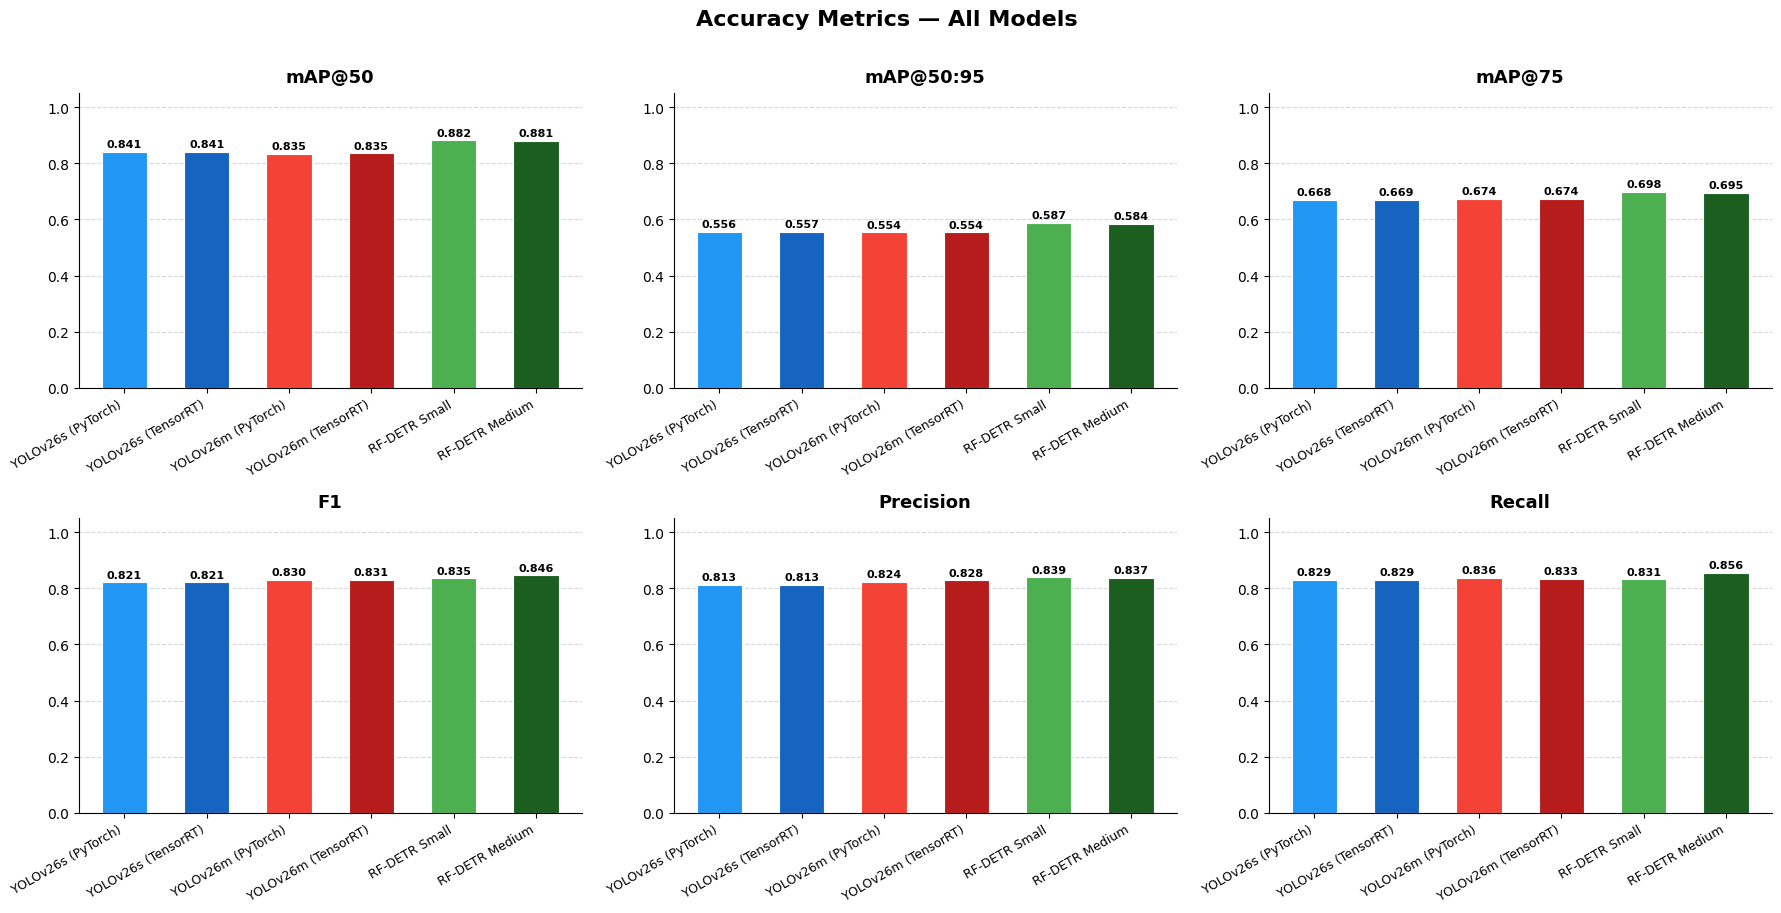

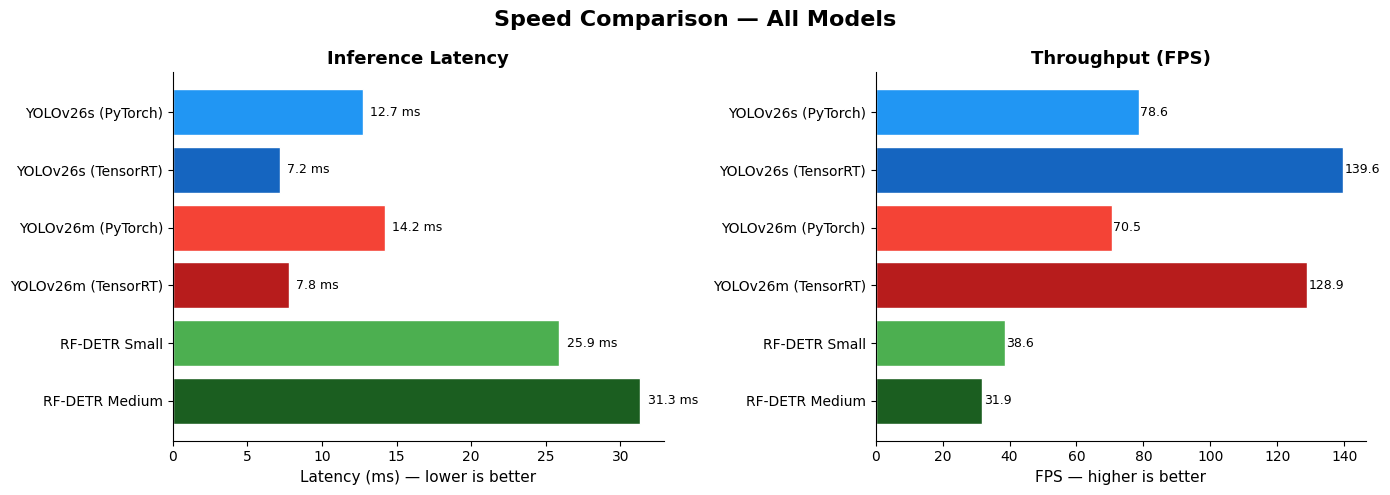

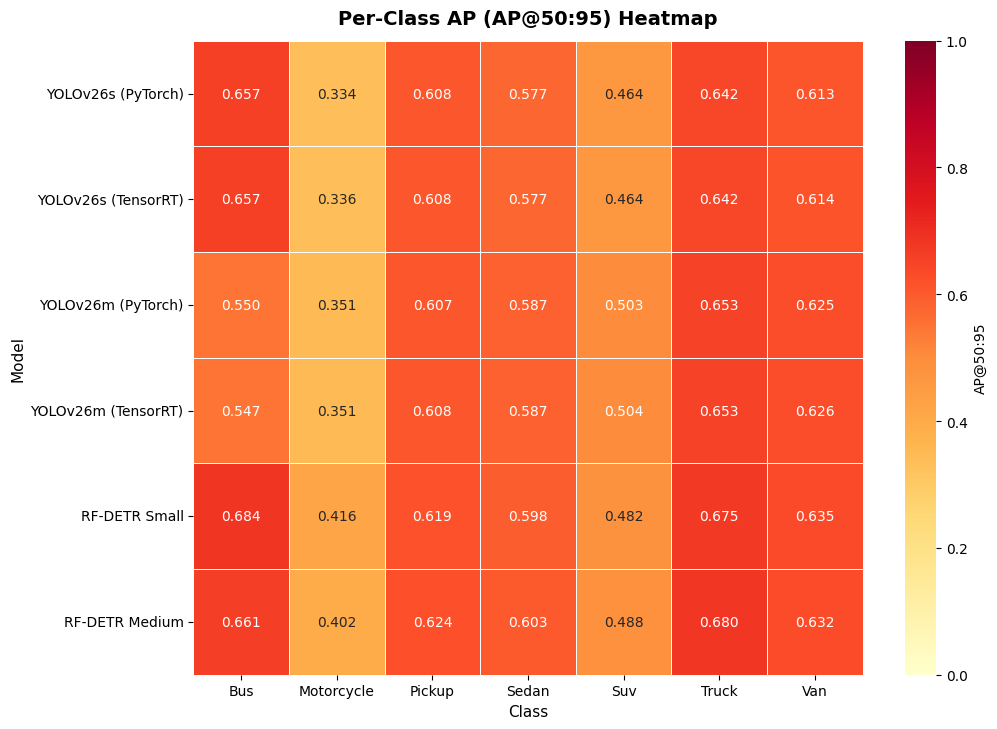

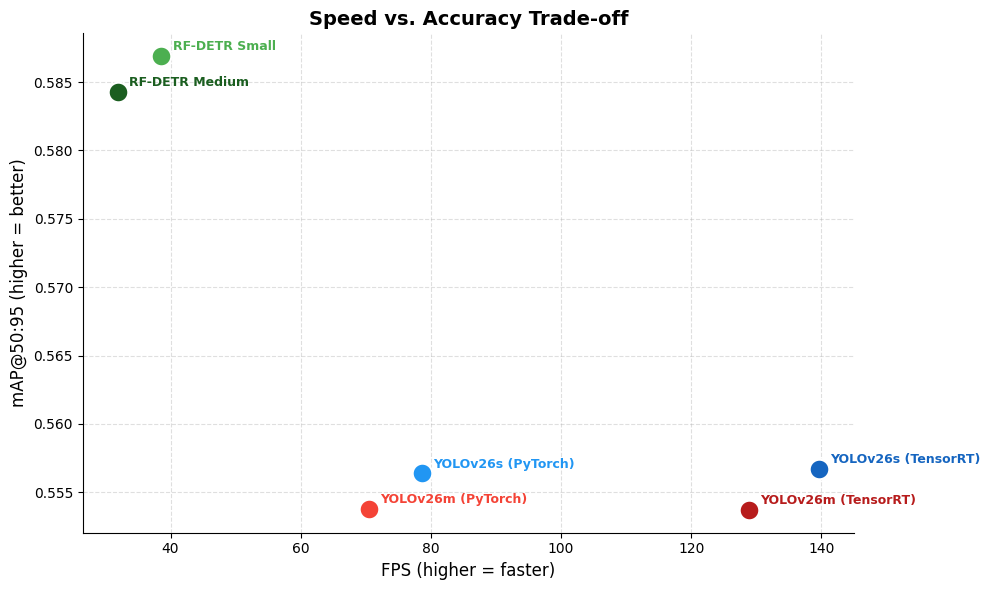

In [10]:
models  = list(summary_df.index)
colors  = ["#2196F3", "#1565C0", "#F44336", "#B71C1C", "#4CAF50", "#1B5E20"]
x       = np.arange(len(models))
bar_w   = 0.55

# ── Figure 1: Accuracy bar chart ─────────────────────────────────────────────
acc_metrics = ["mAP@50", "mAP@50:95", "mAP@75", "F1", "Precision", "Recall"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, metric in zip(axes, acc_metrics):
    vals = summary_df[metric].values
    bars = ax.bar(x, vals, color=colors[:len(models)], width=bar_w,
                  edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontsize=13, fontweight="bold", pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.suptitle("Accuracy Metrics — All Models", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("benchmark_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Figure 2: Speed chart ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

lat_vals = summary_df["Latency (ms)"].values
fps_vals = summary_df["FPS"].values

b1 = ax1.barh(models[::-1], lat_vals[::-1], color=colors[:len(models)][::-1],
               edgecolor="white")
ax1.set_xlabel("Latency (ms) — lower is better", fontsize=11)
ax1.set_title("Inference Latency", fontsize=13, fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)
for bar, val in zip(b1, lat_vals[::-1]):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f} ms", va="center", fontsize=9)

b2 = ax2.barh(models[::-1], fps_vals[::-1], color=colors[:len(models)][::-1],
               edgecolor="white")
ax2.set_xlabel("FPS — higher is better", fontsize=11)
ax2.set_title("Throughput (FPS)", fontsize=13, fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)
for bar, val in zip(b2, fps_vals[::-1]):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}", va="center", fontsize=9)

plt.suptitle("Speed Comparison — All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("benchmark_speed.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Figure 3: Per-class AP heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(per_class_df.columns) * 1.5),
                                 len(per_class_df) * 0.9 + 2))
sns.heatmap(per_class_df.astype(float), annot=True, fmt=".3f",
            cmap="YlOrRd", linewidths=0.5, linecolor="white",
            vmin=0, vmax=1, ax=ax, cbar_kws={"label": "AP@50:95"})
ax.set_title("Per-Class AP (AP@50:95) Heatmap", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.tight_layout()
plt.savefig("benchmark_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Figure 4: Speed-Accuracy scatter ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, (model_name, row) in enumerate(summary_df.iterrows()):
    ax.scatter(row["FPS"], row["mAP@50:95"], s=200, color=colors[i],
               zorder=5, label=model_name, edgecolors="white", linewidths=1.5)
    ax.annotate(model_name,
                xy=(row["FPS"], row["mAP@50:95"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=9, color=colors[i], fontweight="bold")

ax.set_xlabel("FPS (higher = faster)", fontsize=12)
ax.set_ylabel("mAP@50:95 (higher = better)", fontsize=12)
ax.set_title("Speed vs. Accuracy Trade-off", fontsize=14, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("benchmark_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## 💾 Cell 10 — Save Results to CSV / JSON

In [11]:
# Summary CSV
summary_df.to_csv("benchmark_summary.csv")
print("Saved: benchmark_summary.csv")

# Per-class CSV
per_class_df.to_csv("benchmark_per_class_ap.csv")
print("Saved: benchmark_per_class_ap.csv")

# Full results JSON (includes per_class_ap embedded)
serialisable = {}
for model_name, metrics in all_results.items():
    serialisable[model_name] = {k: (v if not isinstance(v, np.floating) else float(v))
                                 for k, v in metrics.items()}
with open("benchmark_full_results.json", "w") as f:
    json.dump(serialisable, f, indent=2)
print("Saved: benchmark_full_results.json")

print("\n✅ All done!")

Saved: benchmark_summary.csv
Saved: benchmark_per_class_ap.csv
Saved: benchmark_full_results.json

✅ All done!
